<a href="https://colab.research.google.com/github/nitishkumar979548-dotcom/thiranex.2/blob/main/project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('housing.csv')

print("Shape:", df.shape)
print("\nColumns and Types:")
print(df.dtypes)
print("\nHead:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSummary Statistics:")
print(df.describe())

Shape: (20640, 10)

Columns and Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Head:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0      

Linear Regression -> RMSE: 69127.04, MAE: 49645.49, R2: 0.6353
Ridge Regression -> RMSE: 69134.97, MAE: 49652.14, R2: 0.6353
Random Forest -> RMSE: 49833.73, MAE: 31926.27, R2: 0.8105

Model Comparison:
               Model          RMSE           MAE        R2
0  Linear Regression  69127.038299  49645.492445  0.635339
1   Ridge Regression  69134.965274  49652.142873  0.635256
2      Random Forest  49833.732394  31926.269673  0.810487


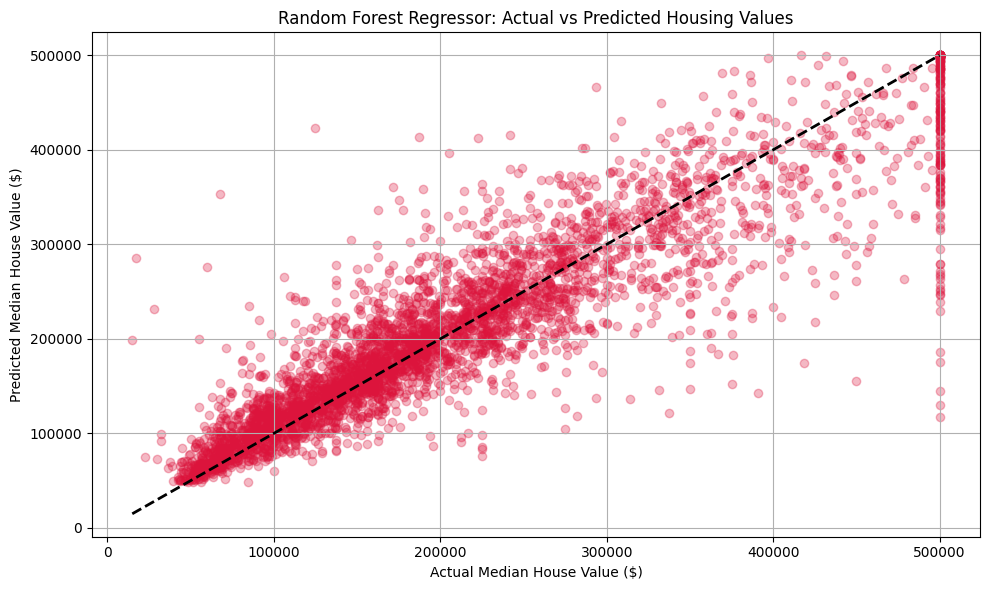

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)



# Create meaningful ratios

df['rooms_per_household'] = (
    df['total_rooms'] / df['households']
)

df['bedrooms_per_room'] = (
    df['total_bedrooms'] / df['total_rooms']
)

df['population_per_household'] = (
    df['population'] / df['households']
)




X = df.drop(
    'median_house_value',
    axis=1
)

y = df['median_house_value']



num_features = X.select_dtypes(
    include=['float64', 'int64']
).columns.tolist()

cat_features = ['ocean_proximity']



num_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])



cat_pipeline = Pipeline([
    (
        'onehot',
        OneHotEncoder(handle_unknown='ignore')
    )
])



preprocessor = ColumnTransformer([
    (
        'num',
        num_pipeline,
        num_features
    ),
    (
        'cat',
        cat_pipeline,
        cat_features
    )
])



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



models = {
    'Linear Regression': LinearRegression(),

    'Ridge Regression': Ridge(
        alpha=1.0
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}



results = {}

for name, model in models.items():

    pipe = Pipeline([
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            model
        )
    ])

    # Train model
    pipe.fit(
        X_train,
        y_train
    )

    # Predictions
    preds = pipe.predict(
        X_test
    )

    # Evaluation metrics
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    mae = mean_absolute_error(
        y_test,
        preds
    )

    r2 = r2_score(
        y_test,
        preds
    )

    # Store results
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'pipeline': pipe,
        'preds': preds
    }

    print(
        f"{name} -> "
        f"RMSE: {rmse:.2f}, "
        f"MAE: {mae:.2f}, "
        f"R2: {r2:.4f}"
    )



comparison = []

for name, result in results.items():

    comparison.append({
        'Model': name,
        'RMSE': result['RMSE'],
        'MAE': result['MAE'],
        'R2': result['R2']
    })

comparison_df = pd.DataFrame(
    comparison
)

print("\nModel Comparison:")
print(comparison_df)



rf_predictions = results[
    'Random Forest'
]['preds']


plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.3,
    color='crimson'
)


# Perfect prediction line

plt.plot(
    [
        y_test.min(),
        y_test.max()
    ],
    [
        y_test.min(),
        y_test.max()
    ],
    'k--',
    lw=2
)


plt.xlabel(
    'Actual Median House Value ($)'
)

plt.ylabel(
    'Predicted Median House Value ($)'
)

plt.title(
    'Random Forest Regressor: '
    'Actual vs Predicted Housing Values'
)

plt.grid(
    True
)

plt.tight_layout()


# Save figure

plt.savefig(
    'actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close()

In [ ]:
# Get Feature Importance from Random Forest model
rf_model = results['Random Forest']['pipeline'].named_steps['model']
preproc = results['Random Forest']['pipeline'].named_steps['preprocessor']

# Get column names after one-hot encoding
cat_encoder = preproc.named_transformers_['cat'].named_steps['onehot']
cat_cols = list(cat_encoder.get_feature_names_out(cat_features))
all_feature_names = num_features + cat_cols

importances = rf_model.feature_importances_
feature_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_imp.plot(kind='barh', color='skyblue')
plt.title('Feature Importances in Predicting Housing Values')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.close()

print(feature_imp.sort_values(ascending=False))

median_income                 0.481545
ocean_proximity_INLAND        0.137497
population_per_household      0.121444
longitude                     0.057863
latitude                      0.056255
housing_median_age            0.044235
rooms_per_household           0.025800
bedrooms_per_room             0.024228
total_rooms                   0.012678
total_bedrooms                0.012304
population                    0.011425
households                    0.010364
ocean_proximity_NEAR OCEAN    0.002207
ocean_proximity_<1H OCEAN     0.001219
ocean_proximity_NEAR BAY      0.000827
ocean_proximity_ISLAND        0.000109
dtype: float64
